<img src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/HydroSARbanner.jpg" width="100%" />

<br>
<font size="6"> <b>FIER Daily Flood Forecasting Code</b><img style="padding: 7px" src="https://radar.community.uaf.edu/wp-content/uploads/sites/667/2021/03/UAFLogo_A_647.png" width="170" align="right"/></font>

<br>
<font size="4"> <b> Franz J Meyer, University of Alaska Fairbanks</b> <br>
</font>

This notebook uses polynomial functions and neural network models to generate daily flood inundation predictions using time series of Sentinel-1 RTC data and GEOGLoWs river runoff forecasts. 
    
The workflow utilizes information available in the fierpy <a href="https://github.com/SERVIR/fierpy">fierpy</a> GitHub repository.
<hr>


# Load Python Libraries

In [38]:
# load needed modules
import _pickle as cPickle
from pathlib import Path
import time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rasterio

***
## Select working folder

In [6]:
from ipyfilechooser import FileChooser
fc = FileChooser(Path.cwd())
display(fc)

FileChooser(path='/home/jovyan/hydrosar', filename='', title='', show_hidden=False, select_desc='Select', chan…

***
## Load saved variables

In [14]:
# Load the variables
start_reload = time.time()
with open(Path(fc_reload.selected,"Forecasting-Files","Forecasting-Files.pkl"), "rb") as f:
    reof_ds = cPickle.load(f) # works
    modes_poly = cPickle.load(f) # works
    degs = cPickle.load(f) # works
    polys = cPickle.load(f) # works
    models_nn = cPickle.load(f) # works
    modes_nn = cPickle.load(f) # works
    q = cPickle.load(f) # works
    q_tot = cPickle.load(f) # works
    type_file = cPickle.load(f) # works
    da_tot = cPickle.load(f) # works
    ind_flood = cPickle.load(f) # works
    floodpercent = cPickle.load(f) # works
    time_flood = cPickle.load(f) # works

end_reload = time.time()

print('It took ',end_reload-start_reload,' seconds to load the variables.')

It took  1.1099424362182617  seconds to load the variables.


## Define important functions

In [10]:
### --- Z-Score calculation --- ###
def z_score(flood_forecast, flood_hindcast):
    # Calculate the indices for scoring: a = true positive, b = false positive, c = false negative, d = true negative
    a = np.sum(np.logical_and(flood_forecast == 1, flood_hindcast == 1))
    b = np.sum(np.logical_and(flood_forecast == 1, flood_hindcast == 0))
    c = np.sum(np.logical_and(flood_forecast == 0, flood_hindcast == 1))
    d = np.sum(np.logical_and(flood_forecast == 0, flood_hindcast == 0))

    # Calculate the skills
    overall_accuracy = ((a + b) / (a + b + c + d)) * 100
    CSI = (a / (a + b + c)) * 100
    precision = (a / (a + b)) * 100
    recall = (a / (a + c)) * 100
    
    # Replace NaNs by 0s
    if np.isnan(overall_accuracy):
        overall_accuracy = 0
    if np.isnan(CSI):
        CSI = 0
    if np.isnan(precision):
        precision = 0
    if np.isnan(recall):
        recall = 0

    return overall_accuracy, CSI, precision, recall
    

***
## Run the forecast

In [15]:
### --- Prepare Discharge dataset --- ###

# Find the index of the first day of the forecast
ind_start = np.where(q_tot.time == q.time[-1])[0][0]

# Find the index of the last day of the forecast
ind_stop = np.where(q_tot.time == da_tot.time[ind_flood])[0][0]

# Crop the discharge to the same range as the forecast
q_forecast = q_tot.isel(time=slice(ind_start, ind_stop + 1))



In [16]:
# define function to create the forecast for a single mode

def mySingleModeForecaster(forecastType, allModes, myMode, q_forecast, reof_ds, models, type_file): 
    # Create the forecast based on a single spatial mode

    # Get dimensions of datasets
    n_modes, y, x = reof_ds.spatial_modes.shape
    t = q_forecast.shape[0]

    # Create the variable filled with zeros
    zeros_variable = np.zeros((t, y, x))

    ### --- Initialize some important arrays --- ###
    
    # Create the new DataArray with zeros_variable
    da = xr.DataArray(
        zeros_variable,
        coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
        dims=['time', 'y', 'x']
    )

    # Make predictions using the best model(s)
    if 'p' in forecastType:
        print('poly ran')
        forecast_rtcp = np.array([model(q_forecast.values) for model in models]).squeeze()
    elif 'n' in forecastType:
        print('neural ran')
        forecast_rtcp = np.array([model.predict(q_forecast.values) for model in models]).squeeze() # original
    else:
        print('Input forecastType is neither neural network nor polynomial!')

    # Check the size of the forecasted rtcps. If it has only one dimension, add a new dimension
    if len(forecast_rtcp.shape) == 1:
        print('this ran')
        forecast_rtcp = forecast_rtcp[:, np.newaxis] # Add a new dimension
        forecast_rtcp = forecast_rtcp.T # Transpose to match the dimensions of the spatial modes

    ### --- Reconstruct the dataset by multiplying the spatial mode by the forecast for each significant mode --- ###
    
    idxM = allModes.index(myMode)
    print(f'myMode = {myMode}')
    print(f'idxM = {idxM}')
    print(f'allModes[idxM] = {allModes[idxM]}')
    forecast_nocenter = np.dot(reof_ds.spatial_modes.sel(mode=allModes[idxM]).values.reshape(-1,1), forecast_rtcp[idxM].reshape(1,len(forecast_rtcp[idxM]))).reshape(y,x,t).transpose(2,0,1)
    for i in range(0,forecast_nocenter.shape[0]):
        forecast_nocenter[i,:,:] = np.flipud(forecast_nocenter[i,:,:])
    

    # Add to the reconstructed dataset
    da.values += forecast_nocenter + reof_ds.center.values

    # If water mask, REOF gives FLOAT we have to round to 0 or 1
    if type_file == 'Water_Masks':
        da.values = np.round(da.values)

    # Convert 255 to NaN
    da.values = np.where(da.values==255, np.nan, da.values)
    
    return da

In [17]:
modes_nn

[1, 8]

In [18]:
modes_poly

[1, 4, 8]

In [21]:
### --- Run forecast on a single mode --- ###
myMode = 1
da_nn = mySingleModeForecaster('neural network',modes_nn, myMode, q_forecast, reof_ds, models_nn, type_file)
da_poly = mySingleModeForecaster('polynomial', modes_poly, myMode, q_forecast, reof_ds, polys, type_file)

neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
myMode = 1
idxM = 0
allModes[idxM] = 1
poly ran
myMode = 1
idxM = 0
allModes[idxM] = 1


***
# Multi-mode Forecast

This code is in progress. It runs, but the resultant forecasts are not as good as the single mode forecast. 

In [22]:
### --- Run forecast on all of the best modes and sum them --- ###

# Get dimensions of datasets
n_modes, y, x = reof_ds.spatial_modes.shape
t = q_forecast.shape[0]

# Create the variable filled with zeros
zeros_variable = np.zeros((t, y, x))

### --- Initialize some important arrays --- ###

# Create the new DataArray with zeros_variable
da_nn_aggregate = xr.DataArray(
    zeros_variable,
    coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
    dims=['time', 'y', 'x']
)
da_poly_aggregate = xr.DataArray(
    zeros_variable,
    coords={'time': q_forecast.time, 'y': reof_ds.y, 'x': reof_ds.x},
    dims=['time', 'y', 'x']
)

type_file_sum = 'none' # making it anything other than 'Water_Masks' prevents the rounding from running, which we need to do after we've summed everything up. 

# Run forecast for the neural network
for mode in modes_nn:
    da_nn_loop = mySingleModeForecaster('neural network',modes_nn, mode, q_forecast, reof_ds, models_nn, type_file_sum) # calculate the forecast for an individual mode
    da_nn_aggregate.values = da_nn_aggregate.values + da_nn_loop.values # collect all of the forecasts
da_nn_aggregate.values = da_nn_aggregate.values / len(modes_nn) # normalize the forecasts
da_nn_aggregate.values = np.round(da_nn_aggregate.values) # round the values since it's either water (>0.5) or it isn't (<0.5)

# Run forecast for the polynomials
# I AM HERE; polynomial forecast is not working correctly
for mode in modes_poly:     
    da_poly_loop = mySingleModeForecaster('polynomial', modes_poly, mode, q_forecast, reof_ds, polys, type_file_sum)
    da_poly_aggregate.values = da_poly_aggregate.values + da_poly_loop.values
da_poly_aggregate.values = da_poly_aggregate.values / len(modes_poly)
da_poly_aggregate.values = np.round(da_poly_aggregate.values)

neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
myMode = 1
idxM = 0
allModes[idxM] = 1
neural ran
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
myMode = 8
idxM = 1
allModes[idxM] = 8
poly ran
myMode = 1
idxM = 0
allModes[idxM] = 1
poly ran
myMode = 4
idxM = 1
allModes[idxM] = 4
poly ran
myMode = 8
idxM = 2
allModes[idxM] = 8


In [63]:
unique_elements, counts = np.unique(da_nn_aggregate[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[  0.   1. 255.]
[1691028  697435 2327846]


In [66]:
unique_elements, counts = np.unique(da_poly_aggregate[-1,:,:], return_counts=True)
print(unique_elements)
print(counts)

[  0.   1. 255.]
[1739669  648794 2327846]


NN Overall accuracy: 35.35%
NN Critical Success Index: 69.79%
NN Precision: 94.00%
NN Recall: 73.05%


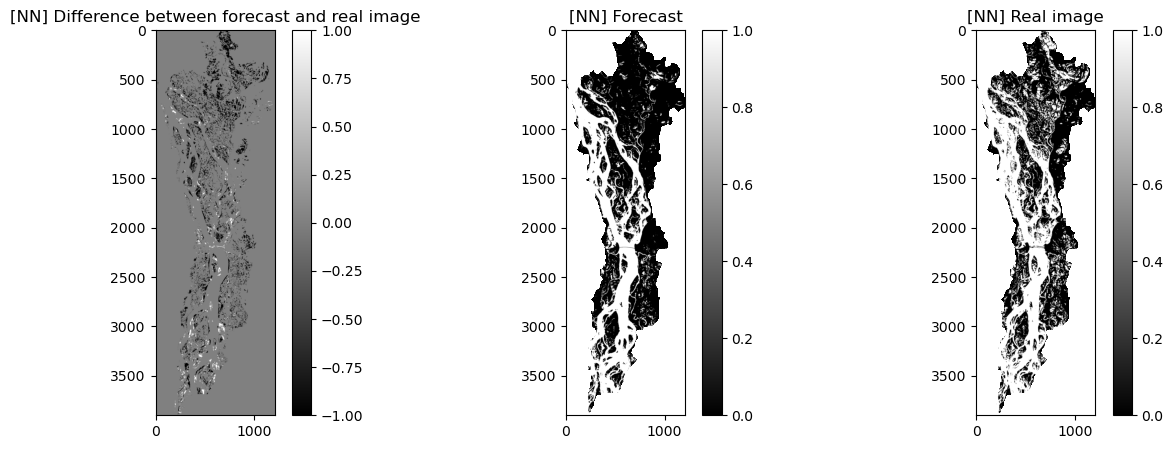

In [51]:
myCmap = 'gray'

### --- Calculate the scores of the forecasts --- ###
if modes_nn != []:
    overall_accuracy, CSI, precision, recall = z_score(da_nn_aggregate.values[-1], da_tot.values[ind_flood])
    print(f"NN Overall accuracy: {overall_accuracy:.2f}%")
    print(f"NN Critical Success Index: {CSI:.2f}%")
    print(f"NN Precision: {precision:.2f}%")
    print(f"NN Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    ## Neural Net
    # Plot the forecast - the real image
    fig_nn_results, ax_nn_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_nn_results[0].imshow(da_nn_aggregate.values[-1] - da_tot.values[ind_flood], vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[0])
    ax_nn_results[0].set_title('[NN] Difference between forecast and real image')

    # Plot the forecast
    im = ax_nn_results[1].imshow(da_nn_aggregate.values[-1], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[1])
    ax_nn_results[1].set_title('[NN] Forecast')

    # Plot the real image
    im = ax_nn_results[2].imshow(da_tot.values[ind_flood], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[2])
    ax_nn_results[2].set_title('[NN] Real image')

    



Polynomial Overall accuracy: 27.16%
Polynomial Critical Success Index: 56.10%
Polynomial Precision: 96.12%
Polynomial Recall: 57.40%


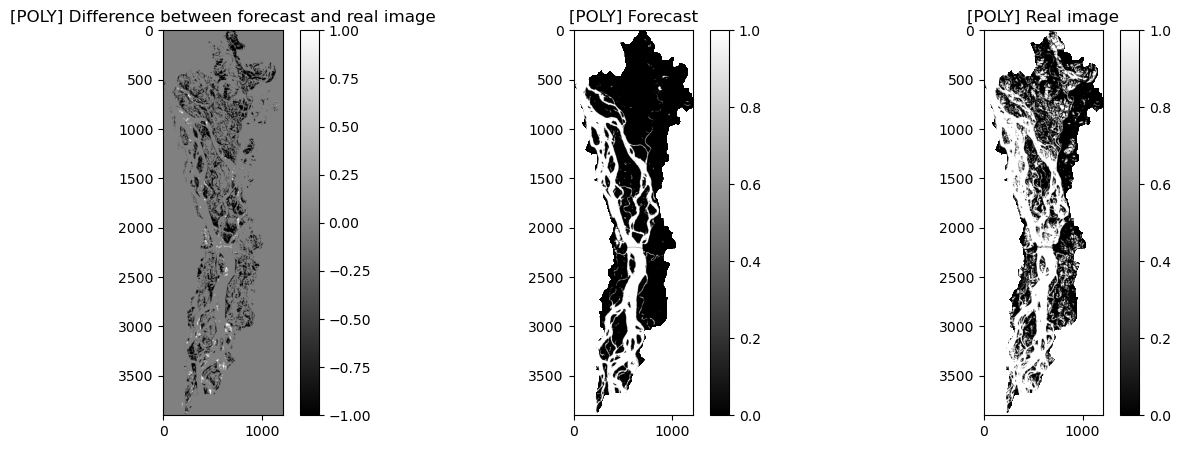

In [67]:
if modes_poly != []:
    overall_accuracy, CSI, precision, recall = z_score(da_poly_aggregate.values[-1], da_tot.values[ind_flood])
    print(f"Polynomial Overall accuracy: {overall_accuracy:.2f}%")
    print(f"Polynomial Critical Success Index: {CSI:.2f}%")
    print(f"Polynomial Precision: {precision:.2f}%")
    print(f"Polynomial Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    # Plot the forecast - the real image
    fig_poly_results, ax_poly_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_poly_results[0].imshow(np.round(da_poly_aggregate.values[-1] - da_tot.values[ind_flood]), vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[0])
    ax_poly_results[0].set_title('[POLY] Difference between forecast and real image')


    # Plot the forecast
    im = ax_poly_results[1].imshow(np.round(da_poly_aggregate.values[-1]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax = ax_poly_results[1])
    ax_poly_results[1].set_title('[POLY] Forecast')

    # Plot the real image
    im = ax_poly_results[2].imshow(np.round(da_tot.values[ind_flood]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[2])
    ax_poly_results[2].set_title('[POLY] Real image')

***
## Accuracy of forecasts

Compare the forecast results to actual flood extent or SAR imagery. 

NN Overall accuracy: 43.62%
NN Critical Success Index: 76.47%
NN Precision: 88.52%
NN Recall: 84.89%
Polynomial Overall accuracy: 50.11%
Polynomial Critical Success Index: 76.15%
Polynomial Precision: 82.46%
Polynomial Recall: 90.86%


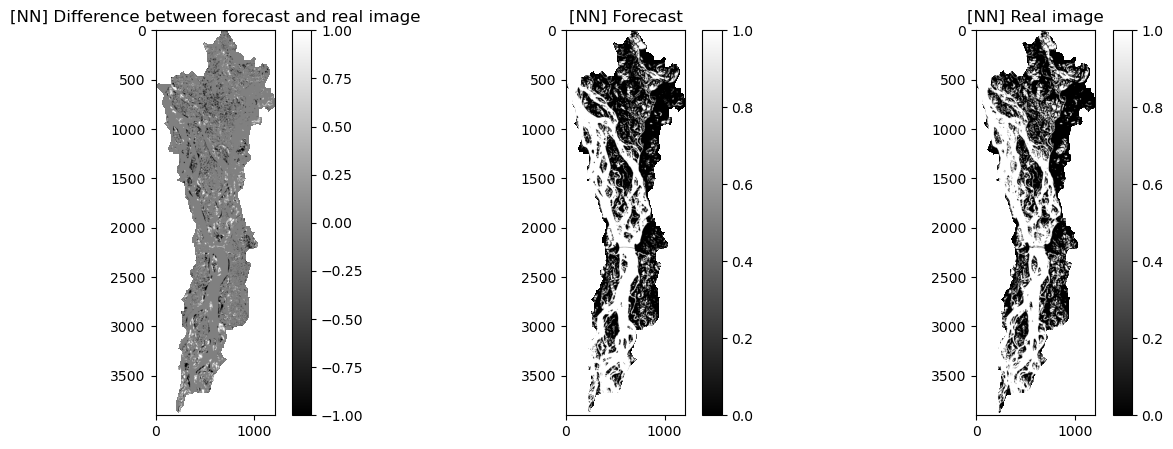

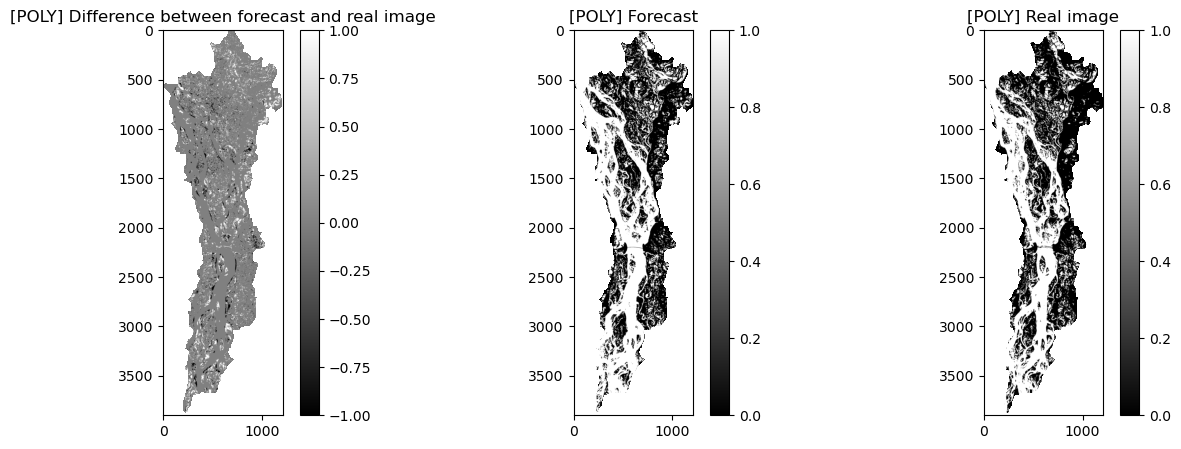

In [25]:
myCmap = 'gray'

### --- Calculate the scores of the forecasts --- ###
if modes_nn != []:
    overall_accuracy, CSI, precision, recall = z_score(da_nn.values[-1], da_tot.values[ind_flood])
    print(f"NN Overall accuracy: {overall_accuracy:.2f}%")
    print(f"NN Critical Success Index: {CSI:.2f}%")
    print(f"NN Precision: {precision:.2f}%")
    print(f"NN Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    ## Neural Net
    # Plot the forecast - the real image
    fig_nn_results, ax_nn_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_nn_results[0].imshow(da_nn.values[-1] - da_tot.values[ind_flood], vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[0])
    ax_nn_results[0].set_title('[NN] Difference between forecast and real image')

    # Plot the forecast
    im = ax_nn_results[1].imshow(da_nn.values[-1], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[1])
    ax_nn_results[1].set_title('[NN] Forecast')

    # Plot the real image
    im = ax_nn_results[2].imshow(da_tot.values[ind_flood], vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_nn_results[2])
    ax_nn_results[2].set_title('[NN] Real image')

    

if modes_poly != []:
    overall_accuracy, CSI, precision, recall = z_score(da_poly.values[-1], da_tot.values[ind_flood])
    print(f"Polynomial Overall accuracy: {overall_accuracy:.2f}%")
    print(f"Polynomial Critical Success Index: {CSI:.2f}%")
    print(f"Polynomial Precision: {precision:.2f}%")
    print(f"Polynomial Recall: {recall:.2f}%")

    ### --- Plot the forecasts --- ###

    # Plot the forecast - the real image
    fig_poly_results, ax_poly_results = plt.subplots(1,3,figsize=(15,5))
    im = ax_poly_results[0].imshow(np.round(da_poly.values[-1] - da_tot.values[ind_flood]), vmin=-1, vmax=1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[0])
    ax_poly_results[0].set_title('[POLY] Difference between forecast and real image')


    # Plot the forecast
    im = ax_poly_results[1].imshow(np.round(da_poly.values[-1]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax = ax_poly_results[1])
    ax_poly_results[1].set_title('[POLY] Forecast')

    # Plot the real image
    im = ax_poly_results[2].imshow(np.round(da_tot.values[ind_flood]), vmin = 0, vmax = 1, cmap=myCmap)
    plt.colorbar(im, ax=ax_poly_results[2])
    ax_poly_results[2].set_title('[POLY] Real image')

***
### Plot of flood forecasts, flood percentages through time, and discharge through time

In [26]:
# define function to plot flood forecasts
def create_subplots(myArray,figsize):

    ncols, nrows = 7,2
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axs = axs.flatten()

    n_plots = myArray.shape[0]

    for i in range(0,n_plots):
        
        axs[i].imshow(myArray[i,:,:], cmap='gray', vmin=0.0, vmax=1.0)
        axs[i].title.set_text(f'{myArray[i].time.dt.strftime("%Y-%m-%d").values}')

    return

In [27]:
# define function to get flood percentages from each flood forecast. 

def floodPercentCalc(forecast): 
    # set up empty array into which to put the percentages
    floodPercent=np.array([])
    # set up the total number of forecasts and a counter to keep track of progress. 
    total = forecast.shape[0]
    county = 0
    print("Starting calcualtion")
    for cast in forecast:
        # get the unique elements and their counts
        unique_elements, counts = np.unique(cast, return_counts=True)
        myDict = dict(zip(unique_elements, counts))
        myArea = myDict[0] + myDict[1]
        flooded = myDict[1]
        floodPercent = np.append(floodPercent, flooded/myArea*100.0)
        county += 1
        print(f"{county} of {total} complete")
    return floodPercent

In [28]:
# define function to plot flood percentage and discharge through time

def plot_flood_and_discharge(forecasts,flood_percents,q_tot, floodpercent_real = [], time_real= []):
    
    # set up figure and twin the axis
    fig_perc_dis, ax1 = plt.subplots(figsize=(9,6))
    ax2 = ax1.twinx()
    
    # plot the neural network flood percentages
    ln1 = ax1.plot(forecasts.time, flood_percents, color='blue', marker='o', label='Predicted Flood Percentage')
    ax1.set_ylabel('Flood Percentage [%]')
    ax1.grid()
    
    # plot the discharge values through same time. 
    idx1, idx2 = np.where(forecasts[0].time == q_tot.time)[0][0], np.where(forecasts[-1].time == q_tot.time)[0][0]
    ln2 = ax2.plot(q_tot[idx1:idx2+1].time, q_tot[idx1:idx2+1], color='red', marker='^', label='Discharge')
    ax2.set_ylabel('Discharge [$m^3/s$]')

    if floodpercent_real.any():
        print('I ran!')
        # I AM HERE
        # find index for relevant times
        # idxA, idxB = np.where(time_real
    
        # add points of relevant times to ax1
    
    # create legend entries
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs)
    
    plt.show()

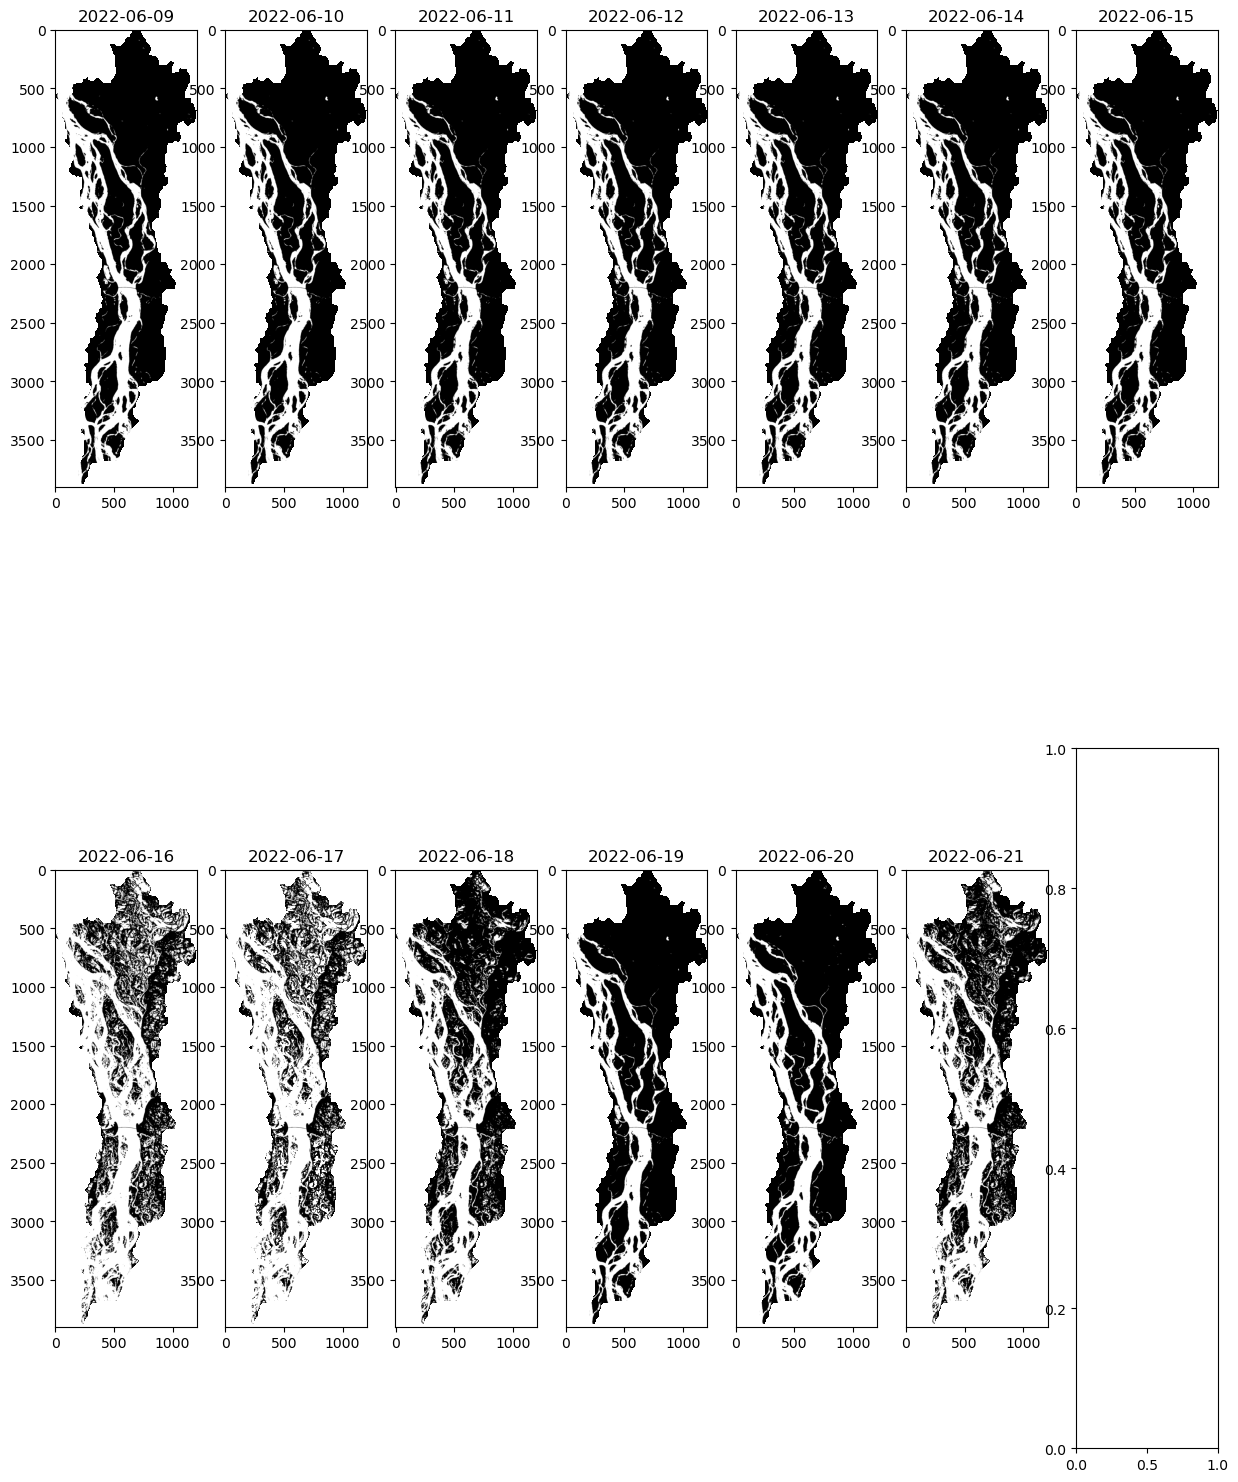

In [29]:
# plot each forecast day for neural network
create_subplots(da_nn,(15,20))

In [30]:
flood_percent_nn = floodPercentCalc(da_nn)

Starting calcualtion
1 of 13 complete
2 of 13 complete
3 of 13 complete
4 of 13 complete
5 of 13 complete
6 of 13 complete
7 of 13 complete
8 of 13 complete
9 of 13 complete
10 of 13 complete
11 of 13 complete
12 of 13 complete
13 of 13 complete


I ran!


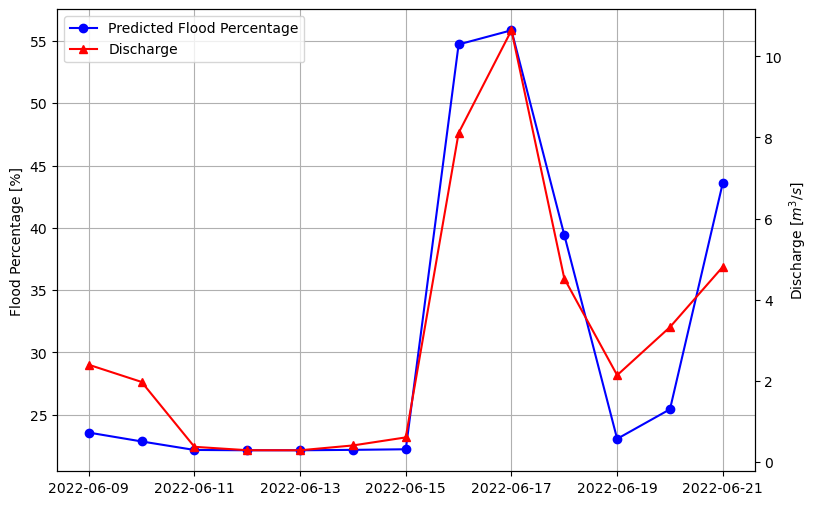

In [31]:
plot_flood_and_discharge(da_nn,flood_percent_nn,q_tot,floodpercent, time_flood)

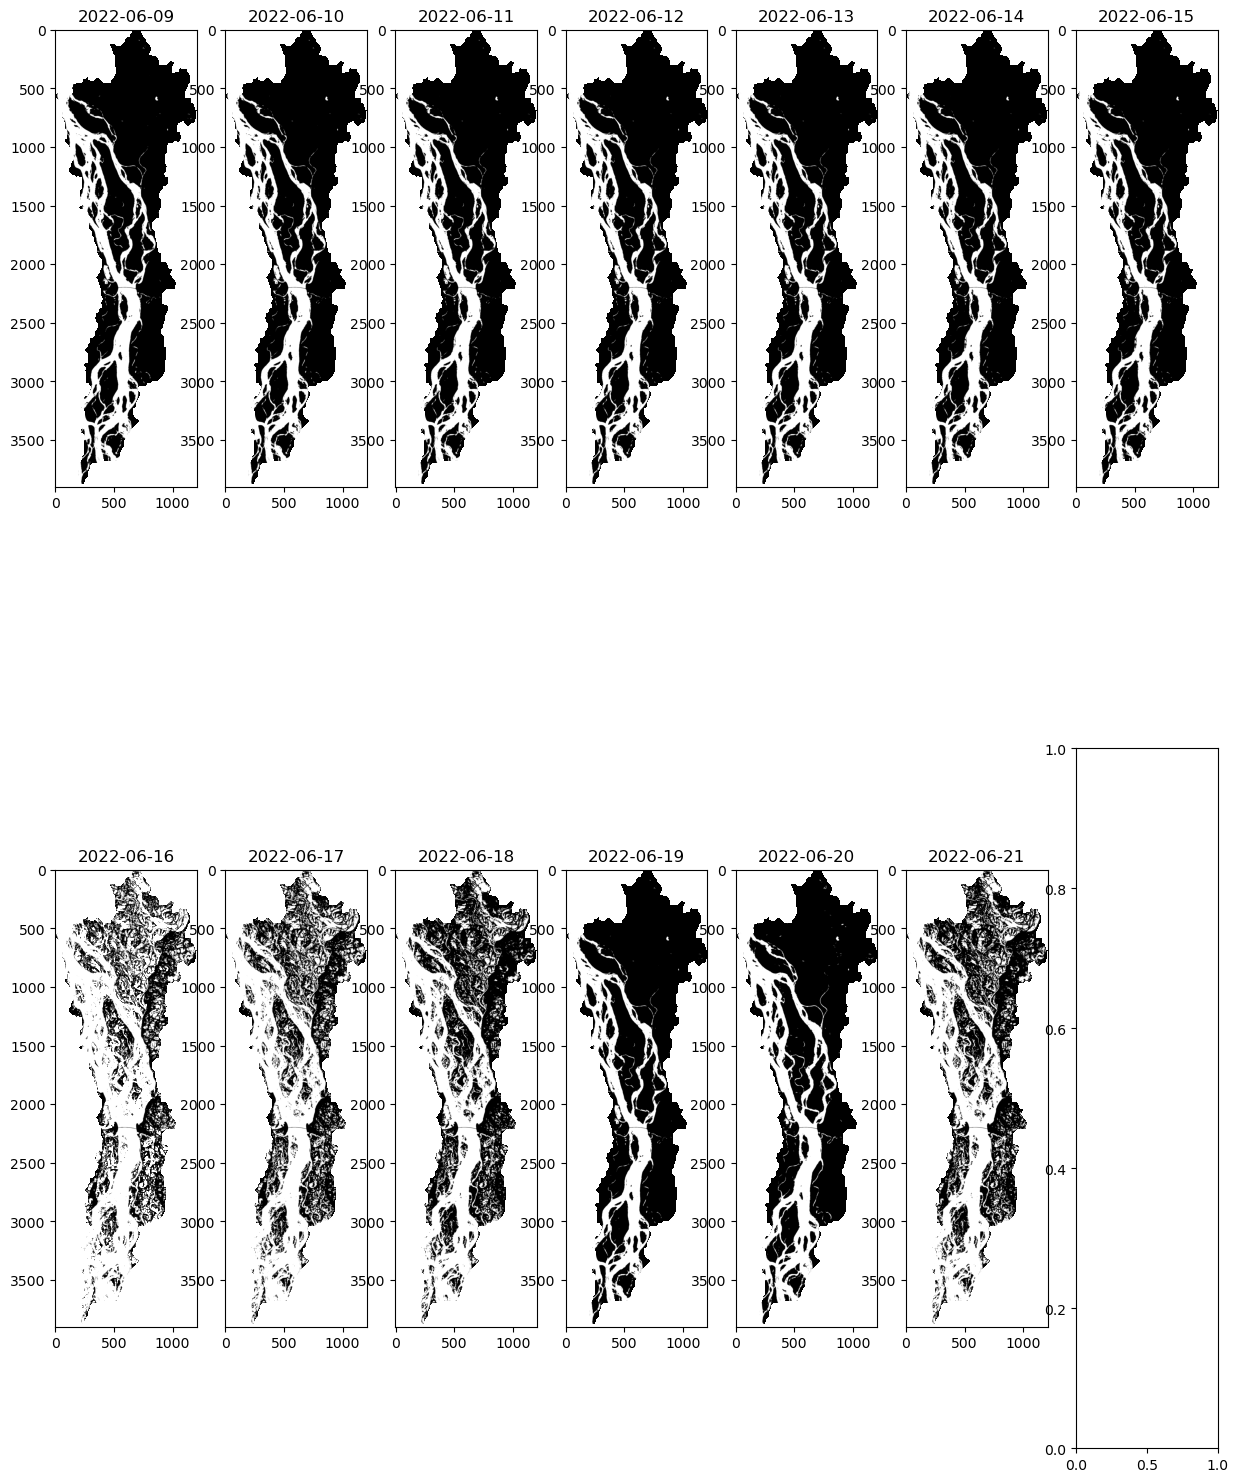

In [32]:
# plot each forecast day for neural network
create_subplots(da_poly,(15,20))

In [33]:
flood_percent_poly = floodPercentCalc(da_poly)

Starting calcualtion
1 of 13 complete
2 of 13 complete
3 of 13 complete
4 of 13 complete
5 of 13 complete
6 of 13 complete
7 of 13 complete
8 of 13 complete
9 of 13 complete
10 of 13 complete
11 of 13 complete
12 of 13 complete
13 of 13 complete


I ran!


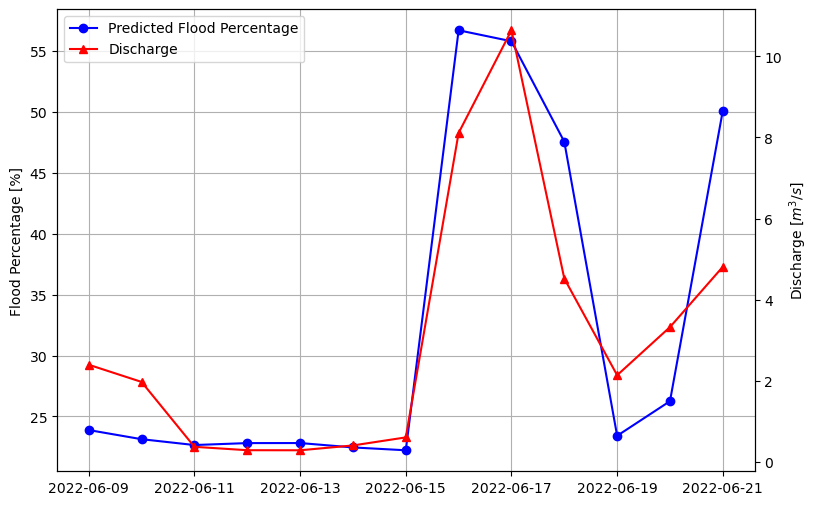

In [34]:
plot_flood_and_discharge(da_poly,flood_percent_poly,q_tot, floodpercent, time_flood)

***
## Save the data files of interest for later loading. 

TO SAVE
* plotted forecasts
* polynomials
* NN
* REOF modes (temporal and spatial)

In [39]:
# I AM HERE; need to improve this; what if they don't have water masks? 
# Load one of the SAR images or water masks in order to get the coordinate reference system. This is used in saving the forecasts as geotiffs. 
folder = fc.selected+'Water_Masks/'
prefix = '*combined'

# Gather names of files corresponding to the file type and polarization we want
tiff_dir = Path(folder)
tiffs = list(tiff_dir.glob(f'{prefix}.tif*'))

raster = rasterio.open(tiffs[0])

raster.crs

CRS.from_epsg(32646)

In [40]:
# Write function to save the forecasts as geotiffs. 
def saveForecasts(saveFolder, da, raster, parent):
    # Make directory if needed
    Path(parent, saveFolder).mkdir(parents=True, exist_ok=True)
    
    county = 1
    for tiff in da:
        # flip the data; it looks upside here, but it saves and displays incorrectly in ArcGIS without it
        # myValues = np.abs(np.flipud(tiff.values))
        myValues = np.abs(tiff.values) # need to take the absolute value as there are some "negative" zero values (I know, negative zero isn't actually a thing; the computer sure thinks it is)
        # create save file name
        file2save = Path(parent,saveFolder,f'Day-{county:02d}_{str(tiff.time.dt.strftime("%Y-%m-%d").values)}.tif')
        print(file2save)
        # open raster file and save
        with rasterio.open(
            file2save,
            mode="w",
            driver="GTiff",
            height=tiff.shape[0],
            width=tiff.shape[1],
            count=1,
            dtype=tiff.dtype,
            crs=raster.crs,
            transform=raster.transform,
        ) as new_dataset:
            new_dataset.write(myValues, 1)
        county += 1
    

In [41]:
# Save files
save_folder = 'forecasts_poly_split-test'
saveForecasts(save_folder, da_poly, raster, fc.selected)
save_folder = 'forecasts_nn_split-test'
saveForecasts(save_folder, da_nn, raster, fc.selected)

/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-01_2022-06-09.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-02_2022-06-10.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-03_2022-06-11.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-04_2022-06-12.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-05_2022-06-13.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-06_2022-06-14.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-07_2022-06-15.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-08_2022-06-16.tif
/home/jovyan/hydrosar/Dataset/bang_NE/subset_bangladesh-West/forecasts_poly_split-test/Day-09_2022-06-17.tif
/home/jovyan/hydros